# Μέρος Α

 Class 0 Parameters 
Mean:
[29.20903802 16.84988855]
Covariance:
[[46.98591258 22.90532295]
 [22.90532295 48.63133559]]

 Class 1 Parameters 
Mean:
[40.19766916 34.28109099]
Covariance:
[[ 9.42390491 11.48971771]
 [11.48971771 20.10805596]]

 Class 2 Parameters 
Mean:
[27.55232503 34.79318037]
Covariance:
[[13.96874391 11.77433636]
 [11.77433636 25.28848192]]



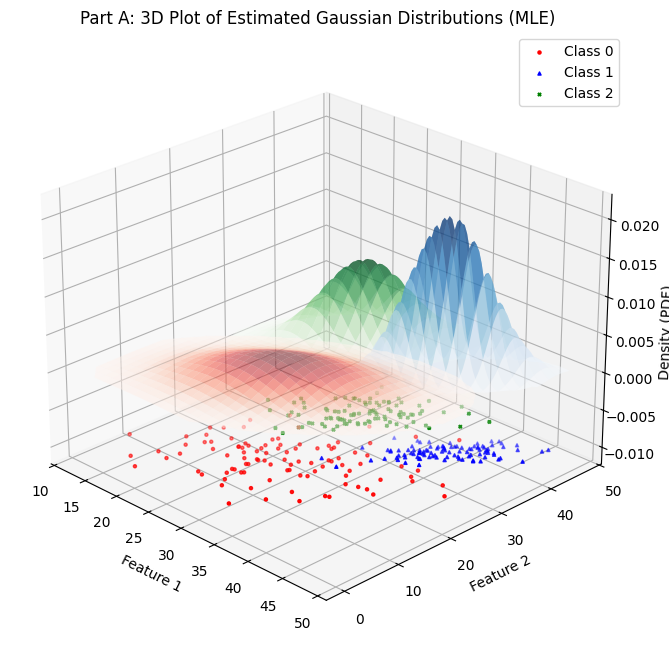

In [ ]:
# Konstantinos Apostolos Kotsopoulos 10969
# Nikolaos Stanotas 1730

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Φόρτωση Δεδομένων
data = np.loadtxt('dataset1.csv', delimiter=',')

# Χωρισμός σε Features (X) και Labels (y)
X = data[:, :2]
y = data[:, 2]

# 0-99: Κλάση 0 / 100-199: Κλάση 1 / 200-299: Κλάση 2
X_c0 = X[0:100, :]
X_c1 = X[100:200, :]
X_c2 = X[200:300, :]


# Μέγιστη Πιθανοφάνεια

def estimate_gaussian_parameters(data_points):
    """
    Υπολογισμός μέσης τιμής και πίνακα συνδιακύμανσης
    χρησιμοποιώντας την τεχνική Μέγιστης Πιθανοφάνειας.
    """
    N = data_points.shape[0] # Πλήθος δειγμάτων

    # Υπολογισμός Μέσης Τιμής (μ)
    # Αθροίζουμε τις στήλες και διαιρούμε με το N
    mu = np.sum(data_points, axis=0) / N

    # Κεντράρισμα δεδομένων
    diff = data_points - mu

    # Σ = (1/N) * sum((x - μ)(x - μ)^T)
    sigma = np.dot(diff.T, diff) / N

    return mu, sigma

# Υπολογισμός παραμέτρων για κάθε κλάση
mu0, sigma0 = estimate_gaussian_parameters(X_c0)
mu1, sigma1 = estimate_gaussian_parameters(X_c1)
mu2, sigma2 = estimate_gaussian_parameters(X_c2)

# Εκτύπωση αποτελεσμάτων
print(" Class 0 Parameters ")
print(f"Mean:\n{mu0}\nCovariance:\n{sigma0}\n")
print(" Class 1 Parameters ")
print(f"Mean:\n{mu1}\nCovariance:\n{sigma1}\n")
print(" Class 2 Parameters ")
print(f"Mean:\n{mu2}\nCovariance:\n{sigma2}\n")

#  Συνάρτηση Πυκνότητας Πιθανότητας

def multivariate_gaussian_pdf(X_grid, mu, sigma):
    """
    Υπολογισμός της τιμής της PDF.
    f(x) = (1 / (sqrt((2π)^k * |Σ|))) * exp(-0.5 * (x-μ)^T * Σ^-1 * (x-μ))
    """
    k = len(mu) # Διάσταση

    # Υπολογισμός ορίζουσας και αντιστρόφου του πίνακα συνδιακύμανσης
    det_sigma = np.linalg.det(sigma)
    inv_sigma = np.linalg.inv(sigma)

    # Σταθερός όρος κανονικοποίησης
    norm_const = 1.0 / (np.sqrt((2 * np.pi) ** k * det_sigma))

    # Υπολογισμός εκθέτη
    diff = X_grid - mu
    # Το (x-μ)^T * Σ^-1 * (x-μ) για κάθε σημείο
    exponent = -0.5 * np.sum(np.dot(diff, inv_sigma) * diff, axis=1)

    return norm_const * np.exp(exponent)

# Σχεδίαση 3D Plot

# Δημιουργία grid για το plot
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Μετατροπή grid σε μορφή λίστας σημείων
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Υπολογισμός του Z (ύψος PDF) για κάθε κλάση
z0 = multivariate_gaussian_pdf(grid_points, mu0, sigma0).reshape(xx.shape)
z1 = multivariate_gaussian_pdf(grid_points, mu1, sigma1).reshape(xx.shape)
z2 = multivariate_gaussian_pdf(grid_points, mu2, sigma2).reshape(xx.shape)

# Σχεδίαση
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Θέτουμε τις πολύ μικρές τιμές σε NaN (Not a Number) για να γίνουν αόρατες
threshold = 0.0001
z0[z0 < threshold] = np.nan
z1[z1 < threshold] = np.nan
z2[z2 < threshold] = np.nan

# Plot επιφανειών
ax.plot_surface(xx, yy, z0, cmap='Reds',  alpha=0.5, rstride=3, cstride=3)
ax.plot_surface(xx, yy, z1, cmap='Blues', alpha=0.5, rstride=3, cstride=3)
ax.plot_surface(xx, yy, z2, cmap='Greens',alpha=0.5, rstride=3, cstride=3)

# Προσθήκη των πραγματικών σημείων στο επίπεδο z=0
ax.scatter(X_c0[:,0], X_c0[:,1], -0.01, c='r', marker='o', s=5, label='Class 0')
ax.scatter(X_c1[:,0], X_c1[:,1], -0.01, c='b', marker='^', s=5, label='Class 1')
ax.scatter(X_c2[:,0], X_c2[:,1], -0.01, c='g', marker='x', s=5, label='Class 2')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Density (PDF)')
ax.set_title('Μέρος Α: 3D Plot Εκτιμώμενων Κανονικών Κατανομών')
ax.legend()
# Ρύθμιση της γωνίας θέασης
ax.view_init(elev=25, azim=-45)
plt.show()

# Μέρος Β

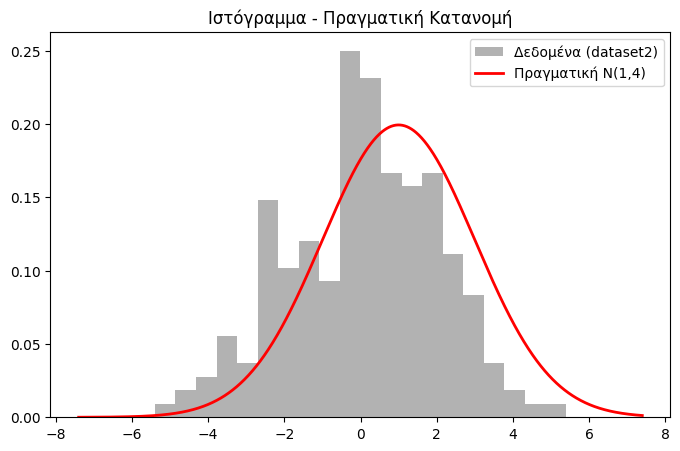

Βέλτιστο h για Υπερκύβο: 2.8 (MSE: 0.001073)
Βέλτιστο h για Gauss:    0.8 (MSE: 0.001117)


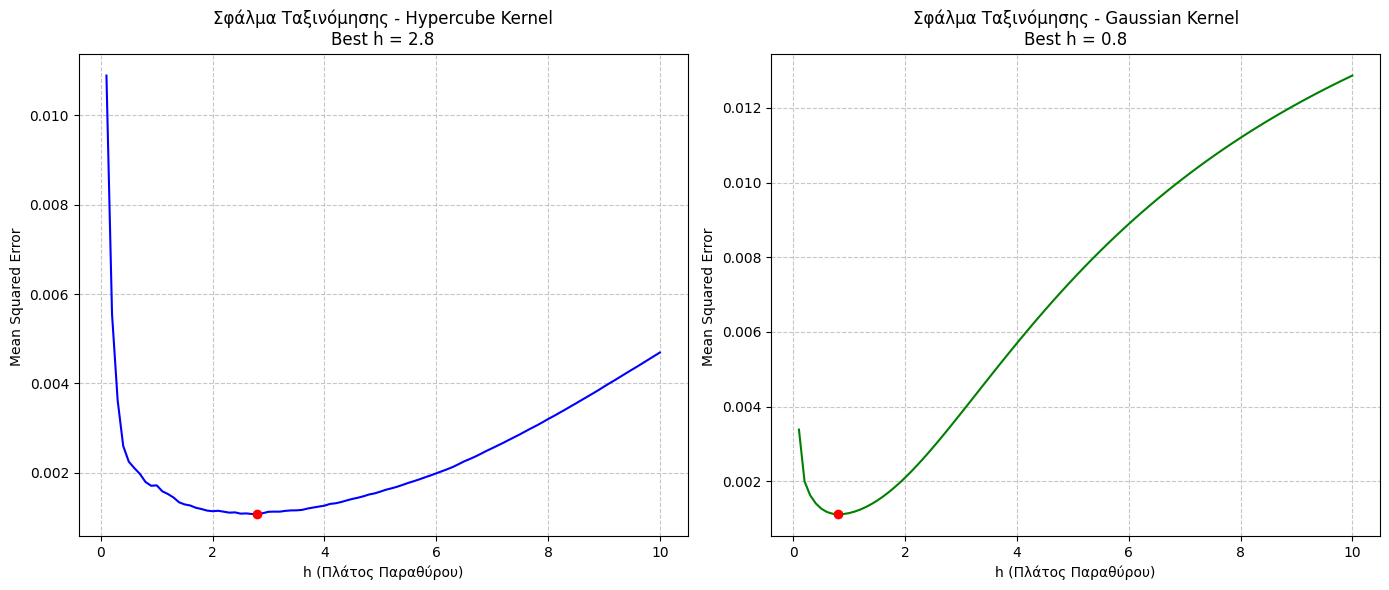

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ορισμός των δύο Kernels
def hypercube_kernel(u):
    """ Υπερκύβος: 1 αν |u| <= 0.5, αλλιώς 0 """
    return (np.abs(u) <= 0.5).astype(float)

def gaussian_kernel(u):
    """ Γκαουσιανή: (1/sqrt(2π)) * exp(-0.5 * u^2) """
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

# Υλοποίηση της τεχνικής Parzen
def parzen_window_estimation(x, data, h, kernel_func):
    """
    x: Το σημείο (ή πίνακας σημείων) στο οποίο θέλουμε να βρούμε την πυκνότητα.
    data: το dataset.
    h: Το πλάτος του παραθύρου.
    kernel_func: Η συνάρτηση πυρήνα (hypercube ή gaussian).
    """
    N = len(data)
    # Αν το x είναι ένα νούμερο, το κάνουμε πίνακα για να δουλεύει ο κώδικας
    if np.isscalar(x):
        x = np.array([x])

    p_x = np.zeros(len(x))

    # p(x) = (1/N) * sum( (1/h) * Kernel((x - xi)/h) )
    for i in range(len(x)):
        u = (x[i] - data) / h
        k_values = kernel_func(u)
        p_x[i] = (1 / (N * h)) * np.sum(k_values)

    return p_x

data = np.loadtxt('dataset2.csv')

# Γνωστή κατανομή N(1, 4) (μ=1, σ=2)
def true_pdf(x):
    return (1 / (np.sqrt(2 * np.pi) * 2)) * np.exp(-0.5 * ((x - 1) / 2)**2)

# Δημιουργία Ιστογράμματος
plt.figure(figsize=(8, 5))
plt.hist(data, bins=20, density=True, alpha=0.6, color='gray', label='Δεδομένα (dataset2)')
# Σχεδίαση της θεωρητικής καμπύλης από πάνω
x_plot = np.linspace(min(data)-2, max(data)+2, 1000)
plt.plot(x_plot, true_pdf(x_plot), 'r-', linewidth=2, label='Πραγματική N(1,4)')
plt.title('Ιστόγραμμα - Πραγματική Κατανομή')
plt.legend()
plt.show()

# Υπολογισμός MSE για κάθε h και για τους δύο Kernels

# Εύρος h: [0.1, 10] με βήμα 0.1
h_values = np.linspace(0.1, 10.0, 100)

# Λίστες για να αποθηκεύσουμε τα σφάλματα
errors_hypercube = []
errors_gaussian = []

# Υπολογίζουμε την πραγματική πιθανότητα για κάθε σημείο των δεδομένων
P_true = true_pdf(data)

# Loop για κάθε h
for h in h_values:
    # Hypercube Kernel
    P_est_hyp = parzen_window_estimation(data, data, h, hypercube_kernel)
    # Υπολογισμός MSE (Mean Squared Error)
    mse_hyp = np.mean((P_true - P_est_hyp)**2)
    errors_hypercube.append(mse_hyp)

    # Gaussian Kernel
    P_est_gauss = parzen_window_estimation(data, data, h, gaussian_kernel)
    # Υπολογισμός MSE
    mse_gauss = np.mean((P_true - P_est_gauss)**2)
    errors_gaussian.append(mse_gauss)

# Αποτελέσματα & Plot Σφαλμάτων

# Εύρεση του βέλτιστου h
min_idx_hyp = np.argmin(errors_hypercube)
best_h_hyp = h_values[min_idx_hyp]

min_idx_gauss = np.argmin(errors_gaussian)
best_h_gauss = h_values[min_idx_gauss]

print(f"Βέλτιστο h για Υπερκύβο: {best_h_hyp:.1f} (MSE: {errors_hypercube[min_idx_hyp]:.6f})")
print(f"Βέλτιστο h για Gauss:    {best_h_gauss:.1f} (MSE: {errors_gaussian[min_idx_gauss]:.6f})")

# Σχεδίαση διαγραμμάτων (h στον άξονα x, σφάλμα στον άξονα y)
plt.figure(figsize=(14, 6))

# Plot για Υπερκύβο
plt.subplot(1, 2, 1)
plt.plot(h_values, errors_hypercube, 'b-', label='Hypercube Error')
plt.scatter(best_h_hyp, errors_hypercube[min_idx_hyp], c='r', zorder=5) # Κόκκινη τελεία στο βέλτιστο
plt.title(f'Σφάλμα Ταξινόμησης - Hypercube Kernel\nBest h = {best_h_hyp:.1f}')
plt.xlabel('h (Πλάτος Παραθύρου)')
plt.ylabel('Μέσο Τετραγωνικό Σφάλμα')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot για Gauss
plt.subplot(1, 2, 2)
plt.plot(h_values, errors_gaussian, 'g-', label='Gaussian Error')
plt.scatter(best_h_gauss, errors_gaussian[min_idx_gauss], c='r', zorder=5) # Κόκκινη τελεία στο βέλτιστο
plt.title(f'Σφάλμα Ταξινόμησης - Gaussian Kernel\nBest h = {best_h_gauss:.1f}')
plt.xlabel('h (Πλάτος Παραθύρου)')
plt.ylabel('Μέσο Τετραγωνικό Σφάλμα')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Μέρος Γ

Καλύτερο k: 11 με Ακρίβεια (Accuracy): 74.00%


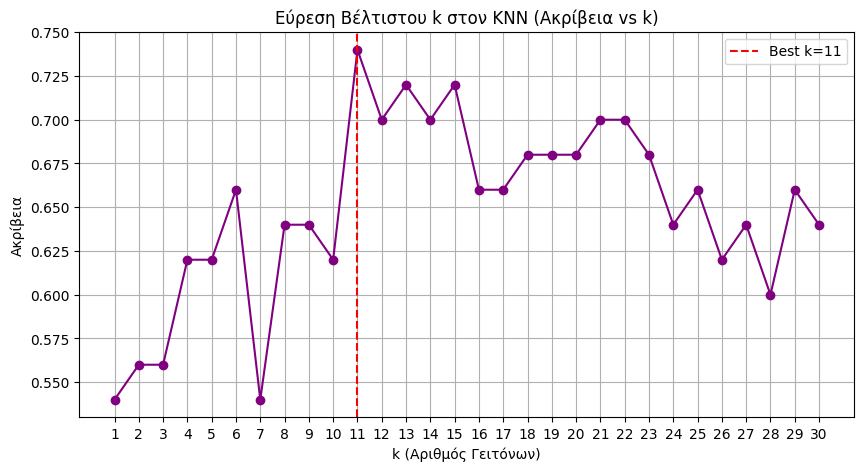

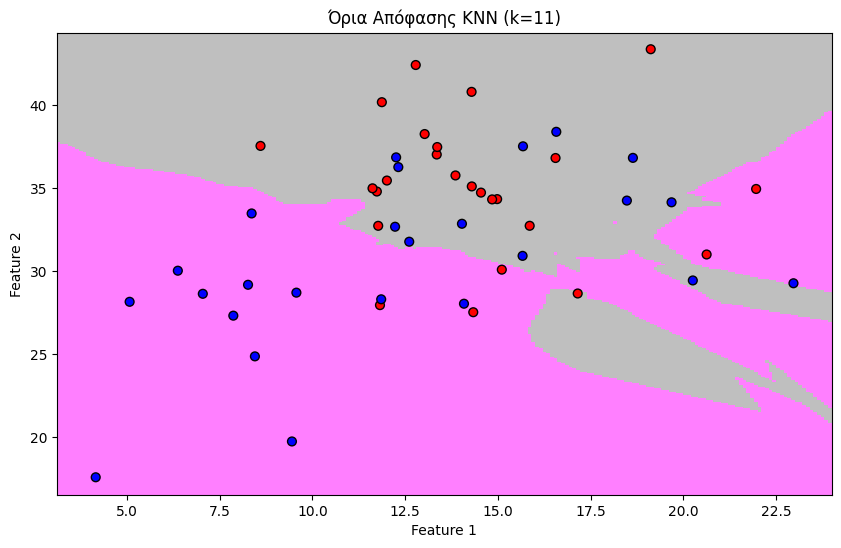

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Φόρτωση training set και test set
train_data = np.loadtxt('dataset3.csv', delimiter=',')
test_data = np.loadtxt('testset.csv', delimiter=',')

# Υλοποίηση Συναρτήσεων KNN
def eucl(x, trainData):
    """
    Υπολογίζει την ευκλείδεια απόσταση του σημείου x από όλα τα σημεία του trainData.
    x: Διάνυσμα (features) ενός σημείου.
    trainData: Ο πίνακας εκπαίδευσης.
    """
    # Παίρνουμε μόνο τα features από το trainData
    features = trainData[:, :2]

    # Διαφορά συντεταγμένων
    diff = features - x

    # Ευκλείδεια απόσταση: sqrt(sum((x - y)^2))
    # axis=1 σημαίνει αθροίζουμε οριζόντια (για κάθε γραμμή)
    dists = np.sqrt(np.sum(diff**2, axis=1))

    return dists

def neighbors(x, trainData, k):
    """
    Επιστρέφει τους k πλησιέστερους γείτονες του x από το trainData.
    """
    # Υπολογισμός αποστάσεων
    distances = eucl(x, trainData)

    # argsort επιστρέφει τους δείκτες των στοιχείων
    # ταξινομημένους από τον μικρότερο στον μεγαλύτερο.
    sorted_indices = np.argsort(distances)

    # Επιλογή των k πρώτων
    top_k_indices = sorted_indices[:k]

    # Επιστροφή των k κορυφαίων σημείων από το trainData
    return trainData[top_k_indices]

def predict(testData, trainData, k):
    """
    Υπολογίζει την πιθανότητα κάθε σημείο του testData να ανήκει στην κλάση 0 ή 1.
    Επιστρέφει πίνακα με τις πιθανότητες.
    """
    n_test = len(testData)
    probabilities = np.zeros((n_test, 2)) # Στήλη 0: Πιθ. Class 0, Στήλη 1: Πιθ. Class 1

    for i in range(n_test):
        # Το σημείο προς εξέταση
        x = testData[i, :2]

        # Βρες τους k γείτονες
        k_neighbors = neighbors(x, trainData, k)

        # Οι ετικέτες των γειτόνων (η 3η στήλη)
        neighbor_labels = k_neighbors[:, 2]

        # Μέτρησε πόσοι είναι κλάση 0 και πόσοι κλάση 1
        count0 = np.sum(neighbor_labels == 0)
        count1 = np.sum(neighbor_labels == 1)

        # Υπολογισμός πιθανοτήτων
        prob0 = count0 / k
        prob1 = count1 / k

        probabilities[i, 0] = prob0
        probabilities[i, 1] = prob1

    return probabilities

# Εύρεση του βέλτιστου k και υπολογισμός Ακρίβειας

accuracy_list = []
k_range = np.linspace(1, 30, 30, dtype=int)

# Οι πραγματικές ετικέτες του Test Set
y_true = test_data[:, 2]

for k in k_range:
    # Προβλεπόμενες πιθανότητες
    probs = predict(test_data, train_data, k)

    # Αν prob1 > prob0 τότε Class 1, αλλιώς Class 0
    y_pred = np.argmax(probs, axis=1)

    # Υπολογισμός Accuracy
    acc = np.mean(y_pred == y_true)
    accuracy_list.append(acc)

# Εύρεση καλύτερου k
best_acc = np.max(accuracy_list)
# Το index 0 αντιστοιχεί σε k=1. Άρα index + 1 = k
best_k = np.argmax(accuracy_list) + 1

print(f"Καλύτερο k: {best_k} με Ακρίβεια (Accuracy): {best_acc * 100:.2f}%")

# Plot: k vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracy_list, '-o', color='purple')
plt.axvline(best_k, color='r', linestyle='--', label=f'Best k={best_k}')
plt.title('Εύρεση Βέλτιστου k στον KNN (Ακρίβεια vs k)')
plt.xlabel('k (Αριθμός Γειτόνων)')
plt.ylabel('Ακρίβεια')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

# Σχεδίαση Ορίων Απόφασης (Decision Boundary)

def plot_decision_boundary(trainData, k):
    # Δημιουργία πλέγματος που καλύπτει όλη την περιοχή των δεδομένων
    x_min, x_max = trainData[:, 0].min() - 1, trainData[:, 0].max() + 1
    y_min, y_max = trainData[:, 1].min() - 1, trainData[:, 1].max() + 1
    h = 0.1 # Βήμα πλέγματος
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Σημεία του grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Περνάμε το πλέγμα σημείων στη συνάρτηση predict.
    probs = predict(grid_points, trainData, k)

    # Κρατάμε την κλάση με τη μέγιστη πιθανότητα
    Z = np.argmax(probs, axis=1)
    Z = Z.reshape(xx.shape)

    # Σχεδίαση
    plt.figure(figsize=(10, 6))

    # Contourf για τις περιοχές απόφασης
    cmap_light = ListedColormap(['gray', 'magenta'])
    cmap_bold = ListedColormap(['red', 'blue'])

    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.5)

    # Scatter plot τα πραγματικά σημεία εκπαίδευσης
    plt.scatter(trainData[:, 0], trainData[:, 1], c=trainData[:, 2],
                cmap=cmap_bold, edgecolor='k', s=40)

    plt.title(f'Όρια Απόφασης KNN (k={k})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Κάλεσμα της συνάρτησης με το καλύτερο k που βρήκαμε
plot_decision_boundary(train_data, best_k)